## Model of "A compute-in-memory chip based on resistive random-access memory", Nature 2022

Paper by Weier Wan, Rajkumar Kubendran, Clemens Schaefer, Sukru Burc Eryilmaz, Wenqiang
Zhang, Dabin Wu, Stephen Deiss, Priyanka Raina, He Qian, Bin Gao, Siddharth Joshi,
Huaqiang Wu, H.-S. Philip Wong, and Gert Cauwenberghs

### Description of The Macro

The macro uses a 256x256 ReRAM array to compute MAC operations. N-bit inputs are
supplied one bit a time as ternary values (positive bits for positive values, negative
bits for negative values, and zero bits for zero values). Outputs from each column of
the array are accumulated in an analog accumulator before being read out by an ADC. The
analog accumulator has the unique ability to accumulate outputs over multiple cycles,
which allows the macro to process variable-bit inputs, accumulate outputs over multiple
cycles, and read out outputs with a single ADC convert.

### Macro Level

- *Input Path*: Inputs are provided to the ternary row drivers to drive rows of the
  array. One input bit is processed in each cycle. For a positive input, the driver will
  supply a positive voltage for a 1 bit and no voltage for a 0 bit. For a negative
  input, the driver will supply a negative voltage for a 1 bit and no voltage for a 0
  bit. The drivers require N cycles to process an N-bit input.
- *Weight Path*: Weight drivers are used to rewrite weights in the array. In the array,
  weights are unsigned values, and negative weights are represented using two arrays in
  parallel (one for positive, one for negative).
- *Output Path*: Outputs are stored in digital circuits which are interspersed
  throughout the array. To tell digital accumulator circuits in the array to generate an
  output bit, wordlines are activated, one for each bit of each output being fetched
  from the array. To charge energy and area for the wordlines, we include two
  components: The wordline capacitance records energy for wordline switching, while the
  wordline drivers account for the area.

Next, there are 256 columns in each macro. Inputs are reused between columns (i.e., each
input-carrying wire connects to all columns), while weights and outputs are not reused.

### Column Level

- *Input Path*: Each input is sent directly to a row in the column.
- *Weight Path*: Each weight is sent directly to a row in the column.
- *Output Path*: Outputs are accumulated between all the rows in the column. After being
  accumulated, they are read by column drivers, then they appear as an analog voltage
  and are sampled by a sampling circuit. After being sampled, each output will be scaled
  by bit position (i.e., the analog value generated by the first input bit is multiplied
  by 1, the analog value generated by the second input bit is multiplied by 2, the
  analog value generated by the third input bit is multiplied by 4, and so on). Scaling
  by N is accomplished by integrating the sampled analog value N times, so processing
  each additional input bit requires twice the number of integration steps as the
  previous bit. After the integrator, the analog output is read by an ADC then passed to
  a shift and add for any required digital accumulation.

To address the exponentially-increasing number of integration steps to process each
additional input bit, the paper proposes two integration approaches.

- The first approach, **one-phase**, processes the first input bit, integrates once,
  processes the second input bit, integrates twice, processes the third input bit,
  integrates four times, and so on. After all input bits are processed, the ADC and
  shift and add read out the output. This approach requires only one ADC convert
  regardless of the number of input bits, but it becomes costly for large N due to the
  high energy and latency of using the integrator many times.
- The second approach, **two-phase**, breaks inputs into 4b slices. For each 4b slice,
  the one-phase approach is used. This approach requires more ADC converts (number of
  input bits divided by 4, rounded up) but limits the exponential growth of the number
  of integration steps.

Finally, the ADC is a variable-precision ADC that can optionally read only the most
significant bits of the analog output. This is used in the two-phase operation to read
only the most-significant bits of the lower-order slice. The upper-order slice is read
in full.

Next, there are 256 rows in each column. Outputs are reused between rows (i.e., analog
outputs are summed on wires that connect rows), while inputs and weights are not reused.

### Row Level

In each row, a ReRAM device stores an analog weight.

- *Input Path*: Analog input voltages are used directly for computation.
- *Weight Path*: Analog weights are stored in the CiM unit, which is a single ReRAM
  device.
- *Output Path*: Computed outputs are passed directly up the hierarchy.

Inside the CiM unit, 4x4 (1b input x 4b weight x 8b output) virtualized MAC units
compute the MAC operation. Note that we chose to use a 4b value for weights, but in
reality the weights are fully analog and the notion of a bit is flexible here.

Some of the important variables for neurram_nature_2022:

- *array_wordlines*: array_parallel_inputs * cim_unit_depth_cells rows in the array
- *array_bitlines*: array_parallel_outputs * cim_unit_width_cells columns in the array
- *array_parallel_inputs*: get_array_fanout_reuse_output(spec) input slice(s) consumed in each cycle.
- *array_parallel_weights*: get_array_fanout_total(spec) weights slice(s) used for computation in each cycle.
- *array_parallel_outputs*: get_array_fanout_reuse_input(spec) partial sums produced in each cycle.
- *tech_node*: 1.3e-07 m
- *adc_resolution*: 8 bit(s)
- *dac_resolution*: max(voltage_dac_resolution, temporal_dac_resolution) bit(s)
- *n_adc_per_bank*: 1 ADC(s)
- *supported_input_bits*: 8 bit(s)
- *supported_output_bits*: 10 bit(s)
- *supported_weight_bits*: 999 bit(s)
- *bits_per_cell*: weight_bits bit(s)
- *cim_unit_width_cells*: 1 adjacent cell(s) in a wordline store bit(s) in one weight slice and process one input & output slice together
- *cim_unit_depth_cells*: 1 adjacent cell(s) in a bitline operate in separate cycles
- *cell_config*: /home/workspace/installs/accelforge/examples/arches/compute_in_memory/memory_cells/rram_neurram_nature_2022.yaml 
- *cycle_period*: base_latency * voltage_latency_scale second(s)

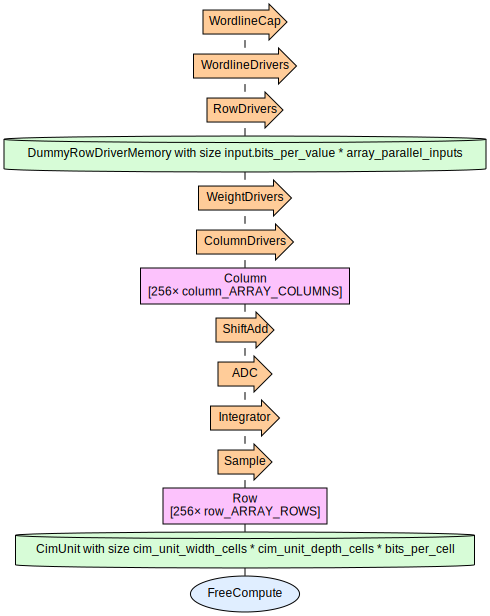

In [1]:
from _scripts import *
from tqdm.auto import tqdm

display_important_variables("neurram_nature_2022")
get_spec("neurram_nature_2022").arch

### Area Breakdown

This test replicates the results of Fig. 11 (f) of the paper.

We show the area of the macro and its subcomponents. We report the area of:

- **Neurons**, which includes the shift add, adc, integrator, and sample components.
- **Array drivers**, which includes the wordline drivers, row drivers, and column
  drivers.
- **RRAMs**, which includes the CiM units.

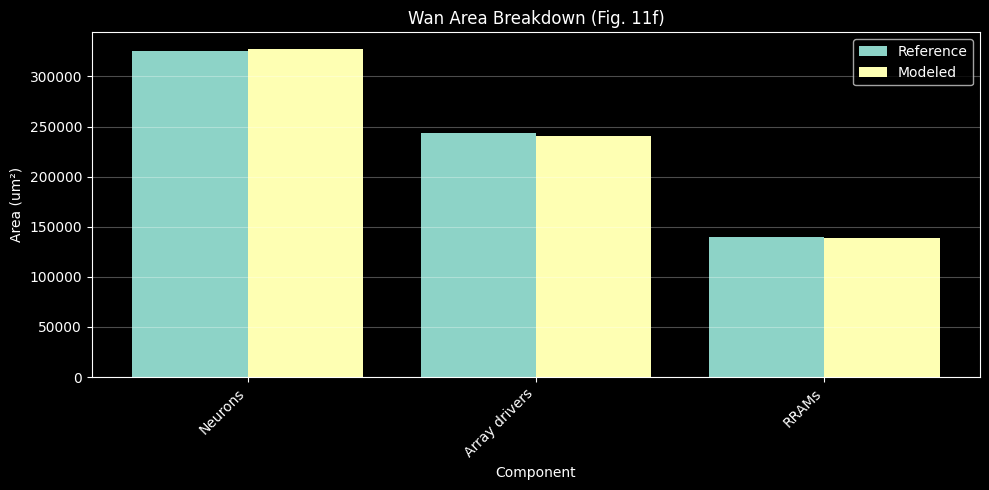

Group                 Modeled    Reference    Ratio
Neurons              327680 um²     325120 um²     1.01x
Array drivers        241044 um²     243840 um²     0.99x
RRAMs                139264 um²     139337 um²     1.00x


In [2]:
area = get_area_breakdown("neurram_nature_2022")

modeled = combine_areas(
    area,
    {
        "Neurons": ["ShiftAdd", "ADC", "Integrator", "Sample"],
        "Array drivers": ["WordlineDrivers", "RowDrivers", "ColumnDrivers"],
        "RRAMs": ["CimUnit"],
    },
)

ref_area = 1270 * 256 / 0.28
reference = {
    "Neurons": ref_area * 0.28 * 1e-12,
    "Array drivers": ref_area * 0.21 * 1e-12,
    "RRAMs": ref_area * 0.12 * 1e-12,
}

modeled_um2 = {k: v * 1e12 for k, v in modeled.items()}
reference_um2 = {k: v * 1e12 for k, v in reference.items()}

fig, ax = plt.subplots(figsize=(10, 5))
bar_comparison(
    {"Reference": reference_um2, "Modeled": modeled_um2},
    "Component",
    "Area (um\u00b2)",
    "Wan Area Breakdown (Fig. 11f)",
    ax,
)
plt.tight_layout()
plt.show()

print(f"{'Group':<16} {'Modeled':>12} {'Reference':>12} {'Ratio':>8}")
for k in reference:
    m = modeled_um2.get(k, 0)
    r = reference_um2.get(k, 0)
    ratio = m / r if r > 0 else float("inf")
    print(f"{k:<16} {m:10.0f} um\u00b2 {r:10.0f} um\u00b2 {ratio:8.2f}x")

### Energy Efficiency and Throughput

This test replicates the results of Fig. 12 (c) and (d) of the paper.

We show the area and energy efficiency and throughput of the macro at varying numbers of
input and output bits. We also compare two-phase and one-phase operation.

Note that this macro uses a signed DAC, which is underutilized for 1b inputs. For this
reason, 1b and 2b inputs required the same number of activations for most circuits, and
therefore the energy and throughput numbers are similar for 1b and 2b inputs.

We see that increasing the number of input and output bits decreases the energy
efficiency and throughput of the macro. This is for two reasons. First, processing each
additional input bit requires an extra cycle and extra activation of most macro
components. Second, each additional output bit requires additional energy to be consumed
by this macro's variable-precision ADC.

We also see that two-phase operation can increase the energy efficiency and throughput
of the macro for >5 input bits and >7 output bits. This is because the macro's
integrator requires 2^N timesteps to process results from an N-bit input slice. The 2^N
scaling can lead to high integrator energy and latency when N is large. Two-phase
operation breaks inputs into two slices to reduce the effect of this scaling. The
two-step operation only kicks in when there are five or more input bits.

We multiply throughput by 48 to model the full Wan-Nature-2022 accelerator chip, which
contains 48 macro tiles operating in parallel.

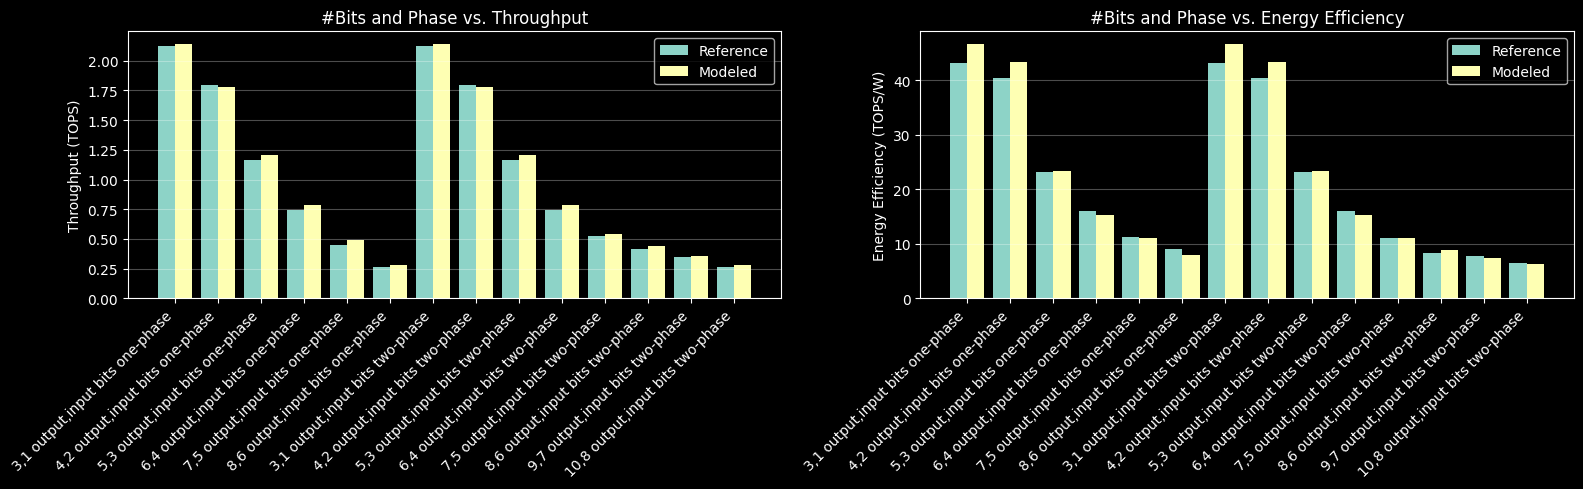

Config                                     TOPS (model)   TOPS (ref)   TOPS/W (model)   TOPS/W (ref)
3,1 output,input bits one-phase                  2.1400       2.1223            46.60          43.08
4,2 output,input bits one-phase                  1.7772       1.7931            43.36          40.33
5,3 output,input bits one-phase                  1.2053       1.1654            23.34          23.09
6,4 output,input bits one-phase                  0.7884       0.7439            15.34          15.95
7,5 output,input bits one-phase                  0.4877       0.4516            10.98          11.33
8,6 output,input bits one-phase                  0.2842       0.2608             8.00           9.12
3,1 output,input bits two-phase                  2.1400       2.1223            46.60          43.08
4,2 output,input bits two-phase                  1.7772       1.7931            43.36          40.33
5,3 output,input bits two-phase                  1.2053       1.1654            23.34      

In [3]:
def _run_wan_tops(output_bits, input_bits, one_phase):
    spec = get_spec("neurram_nature_2022", add_dummy_main_memory=True)
    spec.arch.variables["one_phase"] = one_phase
    for einsum in spec.workload.einsums:
        for ta in einsum.tensor_accesses:
            if ta.name == "input":
                ta.bits_per_value = input_bits
            elif ta.name == "output":
                ta.bits_per_value = output_bits
    spec_eval = spec._spec_eval_expressions(einsum_name="Matmul")
    pc = spec.map_workload_to_arch(print_progress=False).per_compute()

    return (
        output_bits,
        input_bits,
        one_phase,
        # 2 ops/MAC
        2 * 48 / pc.latency() / 1e12,  # x48 for the 48-tile chip's total throughput
        2 * 1 / pc.energy() / 1e12,
    )


# (output_bits, input_bits, one_phase) -> (TOPS, TOPS/W)
ref_tops = {
    (3, 1, 1): (2.12230988, 43.07875866),
    (4, 2, 1): (1.793083771, 40.33412834),
    (5, 3, 1): (1.165400233, 23.09069279),
    (6, 4, 1): (0.7438677864, 15.95409517),
    (7, 5, 1): (0.4515642, 11.32999012),
    (8, 6, 1): (0.260797508, 9.12235241),
    (3, 1, 0): (2.12230988, 43.07875866),
    (4, 2, 0): (1.793083771, 40.33412834),
    (5, 3, 0): (1.165400233, 23.09069279),
    (6, 4, 0): (0.7438677864, 15.95409517),
    (7, 5, 0): (0.5254091287, 11.03166076),
    (8, 6, 0): (0.4177183338, 8.257196816),
    (9, 7, 0): (0.343873405, 7.750037817),
    (10, 8, 0): (0.2638743409, 6.437388185),
}

tops_out = parallel([delayed(_run_wan_tops)(*c) for c in ref_tops])


def fmt_name(o, i, p):
    return f"{o},{i} output,input bits {'one' if p else 'two'}-phase"


labels = [fmt_name(o, i, p) for o, i, p, _, _ in tops_out]
ref_t = [ref_tops[(o, i, p)][0] for o, i, p, _, _ in tops_out]
ref_tw = [ref_tops[(o, i, p)][1] for o, i, p, _, _ in tops_out]
mod_t = [t for _, _, _, t, _ in tops_out]
mod_tw = [tw for _, _, _, _, tw in tops_out]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bar_comparison(
    {"Reference": dict(zip(labels, ref_t)), "Modeled": dict(zip(labels, mod_t))},
    "",
    "Throughput (TOPS)",
    "#Bits and Phase vs. Throughput",
    axes[0],
)
bar_comparison(
    {"Reference": dict(zip(labels, ref_tw)), "Modeled": dict(zip(labels, mod_tw))},
    "",
    "Energy Efficiency (TOPS/W)",
    "#Bits and Phase vs. Energy Efficiency",
    axes[1],
)
plt.tight_layout()
plt.show()

print(
    f"{'Config':<40} {'TOPS (model)':>14} {'TOPS (ref)':>12} {'TOPS/W (model)':>16} {'TOPS/W (ref)':>14}"
)
for o, i, p, t, tw in tops_out:
    rt, rtw = ref_tops[(o, i, p)]
    print(f"{fmt_name(o, i, p):<40} {t:14.4f} {rt:12.4f} {tw:16.2f} {rtw:14.2f}")

### Energy Breakdown and Number of Input and Output Bits

This test replicates the results of Fig. 12 (b) of the paper.

We show the energy of different components of the macro at varying numbers of input and
output bits. We will show three categories:

- **Neuron operations and control** (1.8 V), which includes the shift_add, adc,
  integrator, and sample components.
- **Input pulses** (Vread = 0.5 V), which includes the row_drivers and cim_unit
  components.
- **WL (Row) Switching** (0.9 V <-> 2.2 V), which includes the wordline_drivers and
  wordline_cap components.

Note that this macro uses a signed DAC, which is underutilized for 1b inputs. For this
reason, 1b and 2b inputs required the same number of activations for most circuits, and
therefore the energy numbers are similar for 1b and 2b inputs.

We see the following:

- Neuron operations and control energy increases linearly with the number of output
  bits. This is because the variable-precision ADC and control logic must process more
  bits, leading to higher energy consumption.
- Input pulses energy increases with the number of input bits. Energy increases
  exponentially as the DAC requires 2^N timesteps to process an N-bit slice, and there
  is a jump at 5 input bits, where the macro switches to two-phase operation.
- WL (row) switching energy increases linearly with the number of input bits, as the
  wordlines are used to supply input values.

For each component, we plot both the modeled energy and the paper reference energy as
separate lines so the two can be compared directly.

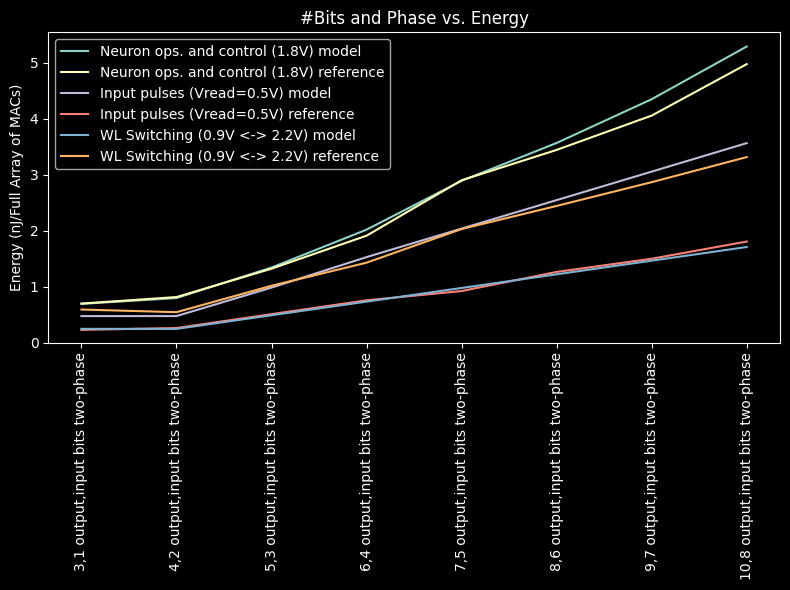

In [4]:
# 256x256 array; 2 devices per signed weight = 256 * 128 MACs, 2 ops/MAC.
ops_per_array = 256 * 128 * 2


def _run_wan_bits(output_bits, input_bits, one_phase):
    spec = get_spec("neurram_nature_2022", add_dummy_main_memory=True)
    spec.arch.variables["one_phase"] = one_phase
    for einsum in spec.workload.einsums:
        for ta in einsum.tensor_accesses:
            if ta.name == "input":
                ta.bits_per_value = input_bits
            elif ta.name == "output":
                ta.bits_per_value = output_bits
    r = spec.map_workload_to_arch(print_progress=False)
    total_energy = {k: float(v) for k, v in r.energy(per_component=True).items()}
    return output_bits, input_bits, one_phase, total_energy


# (output_bits, input_bits, one_phase) -> (WL switching, neuron ops, input pulses) in fJ/MAC
ref_energy_bits = {
    (3, 1, 0): (8.99015248, 10.6186848, 3.446220545),
    (4, 2, 0): (8.270951256, 12.38674172, 3.955661604),
    (5, 3, 0): (15.46307324, 20.11826462, 7.73153662),
    (6, 4, 0): (21.75617998, 29.1084171, 11.50740478),
    (7, 5, 0): (30.92613276, 44.21188287, 14.0246365),
    (8, 6, 0): (37.2192395, 52.48282041, 19.23892768),
    (9, 7, 0): (43.69214654, 61.83258722, 22.83498524),
    (10, 8, 0): (50.52466791, 75.85721686, 27.50986693),
}

two_phase_configs = list(ref_energy_bits)
bits_out = parallel(
    [delayed(_run_wan_bits)(o, i, p) for (o, i, p) in two_phase_configs]
)

groups = {
    "Neuron ops. and control (1.8V)": [
        "ShiftAdd",
        "ADC",
        "Integrator",
        "Sample",
        "WeightDrivers",
    ],
    "Input pulses (Vread=0.5V)": ["RowDrivers", "CimUnit"],
    "WL Switching (0.9V <-> 2.2V)": ["WordlineDrivers", "WordlineCap"],
}

ref_keys = (
    "WL Switching (0.9V <-> 2.2V)",
    "Neuron ops. and control (1.8V)",
    "Input pulses (Vread=0.5V)",
)

# Match CL: total energy J -> nJ, ref fJ/MAC * ops_per_array / 1e15 J -> nJ.
line_data = {}
for o, i, p, en in bits_out:
    label = f"{o},{i} output,input bits {'one' if p else 'two'}-phase"
    grouped = combine_energies(en, groups)
    ref_vals = dict(zip(ref_keys, ref_energy_bits[(o, i, p)]))
    entry = {}
    for g in groups:
        entry[f"{g} model"] = grouped.get(g, 0) * 1e9
        entry[f"{g} reference"] = ref_vals.get(g, 0) * ops_per_array / 1e6
    line_data[label] = entry

fig, ax = plt.subplots(figsize=(8, 6))
x_labels = list(line_data.keys())
x_pos = list(range(len(x_labels)))
series_keys = list(next(iter(line_data.values())).keys())
for key in series_keys:
    y = [line_data[lbl][key] for lbl in x_labels]
    ax.plot(x_pos, y, label=key)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=90)
ax.set_xlabel("")
ax.set_ylabel("Energy (nJ/Full Array of MACs)")
ax.set_title("#Bits and Phase vs. Energy")
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.show()

### Exploration of Array Size versus DNN Energy Efficiency

In this test, we explore the energy efficiency of the macro at varying array sizes for
different DNNs. We will set the number of input bits to 8, the number of output bits to
10, and we show the area array sizes 64x64, 128x128, 256x256, 512x512, 1024x1024, and
2048x2048. We will compare the energy efficiency of the macro for different DNNs.

We see that, as the array size increases:

- Energy for ADC and output processing decreases because the number of array rows
  increases, leading to more analog output reuse and fewer ADC converts.
- Energy for DAC decreases because the number of array columns increases, leading to
  more analog input reuse and fewer DAC converts. Input processing energy decreases less
  than does output processing energy because input processing pays energy to drive
  high-capacitance row wires, the capacitance of which increases with the array size.
  This increase cancels some of the energy savings from input reuse.

The energy benefits of larger arrays are strongest for maximum-utilization and
large-tensor-size workloads. For medium-tensor-size workloads, the energy benefits of
larger arrays saturate as the array grows larger and becomes underutilized for smaller
layers. For small-tensor-size workloads, underutilization increases energy for all array
sizes and leads to a smaller array being the lowest-energy choice.


DNN x array size: 100%|██████████| 24/24 [00:46<00:00,  1.94s/it]


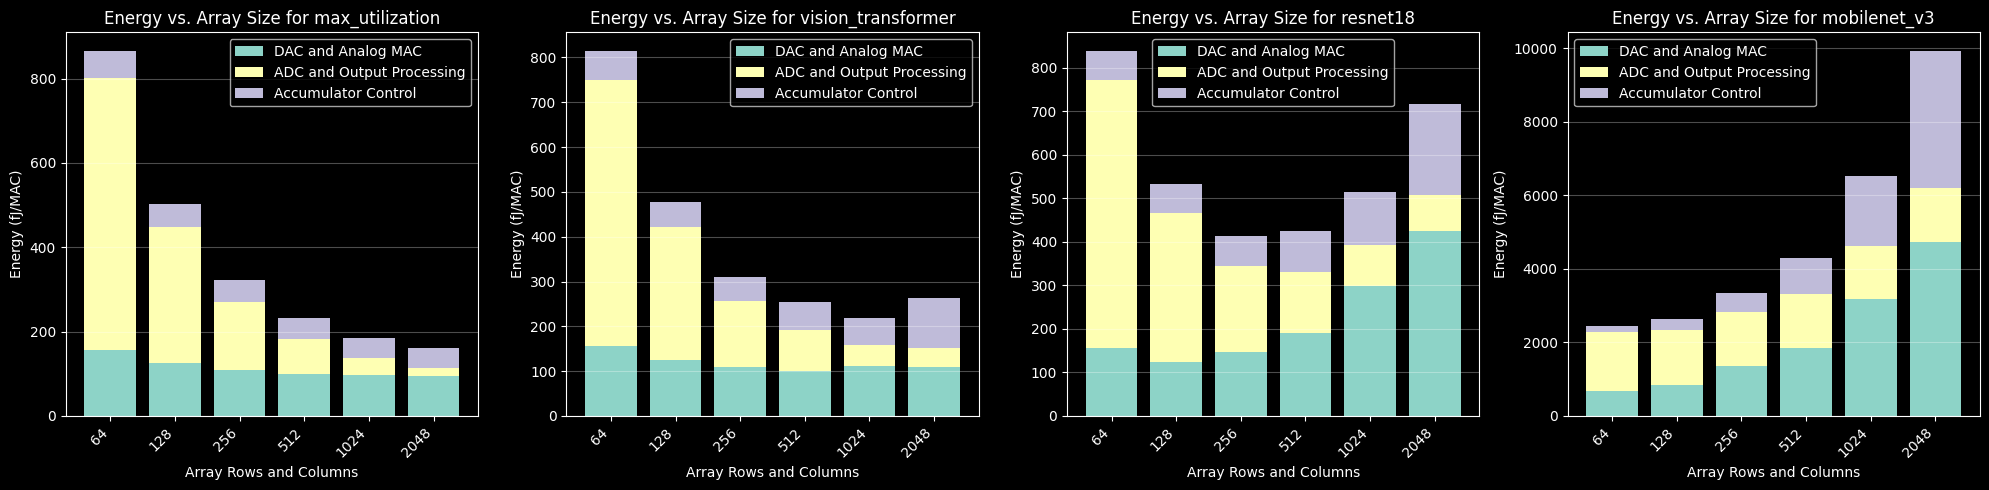

DNN                     Array        ADC and Output Processing               DAC and Analog MAC              Accumulator Control
max_utilization            64                           645.01                           155.91                            65.33
max_utilization           128                           322.50                           124.48                            56.48
max_utilization           256                           161.25                           108.66                            52.05
max_utilization           512                            80.63                           100.71                            49.84
max_utilization          1024                            40.31                            96.50                            48.73
max_utilization          2048                            20.16                            93.75                            48.18
vision_transformer         64                           593.95                           155.86  

In [5]:
array_sizes = [64, 128, 256, 512, 1024, 2048]

array_size_groups = {
    "ADC and Output Processing": ["ShiftAdd", "ADC", "Integrator", "Sample"],
    "DAC and Analog MAC": ["RowDrivers", "CimUnit"],
    "Accumulator Control": ["WordlineDrivers", "WordlineCap"],
}


def _set_wan_array_size(spec, x):
    spec.arch.variables["array_rows"] = x
    spec.arch.variables["array_cols"] = x
    spec.arch.find("Column").spatial[0].fanout = x
    spec.arch.find("Row").spatial[0].fanout = x


def _build_wan_dnn_spec(dnn, x):
    spec = get_spec("neurram_nature_2022", add_dummy_main_memory=True, n_macros=1)
    _set_wan_array_size(spec, x)
    spec.arch.variables["one_phase"] = 0

    if dnn == "max_utilization":
        spec.workload.rank_sizes["N"] = x
        spec.workload.rank_sizes["K"] = x
        for einsum in spec.workload.einsums:
            for ta in einsum.tensor_accesses:
                if ta.name == "input":
                    ta.bits_per_value = 8
                elif ta.name == "output":
                    ta.bits_per_value = 10
        return spec

    workload_path = getattr(af.examples.workloads.compute_in_memory, dnn)
    parse = {"BATCH_SIZE": 1}
    workload = af.Workload.from_yaml(
        workload_path, top_key="workload", jinja_parse_data=parse
    )
    renames = af.Renames.from_yaml(
        workload_path, top_key="renames", jinja_parse_data=parse
    )
    workload.einsums = workload.einsums[:10]  # First 10 Einsums only
    spec.workload = workload
    spec.renames = renames
    for einsum in spec.workload.einsums:
        for ta in einsum.tensor_accesses:
            if ta.name == "input":
                ta.bits_per_value = 8
            elif ta.name == "output":
                ta.bits_per_value = 10
    spec.mapper.metrics = af.Metrics.ENERGY
    spec.mapper.explore_loop_orders = False
    return spec


def _run_wan_array_size(dnn, x):
    spec = _build_wan_dnn_spec(dnn, x)
    r = spec.map_workload_to_arch(one_pbar_only=True)
    return (
        dnn,
        x,
        {k: float(v) for k, v in r.per_compute().energy(per_component=True).items()},
    )


dnns = ["max_utilization", "vision_transformer", "resnet18", "mobilenet_v3"]

# Every (DNN, array size) pair; the mapper parallelizes einsums internally.
jobs = [(d, x) for d in dnns for x in array_sizes]

results_by_dnn = {d: {} for d in dnns}
for d, x, energy in parallel(
    [delayed(_run_wan_array_size)(d, x) for d, x in jobs],
    pbar="DNN x array size",
):
    results_by_dnn[d][x] = energy

fig, axes = plt.subplots(1, len(dnns), figsize=(5 * len(dnns), 5))
for ax, d in zip(axes, dnns):
    stacked = {
        str(x): {
            k: v * 1e15
            for k, v in combine_energies(en, array_size_groups).items()
            if v > 0
        }
        for x, en in results_by_dnn[d].items()
    }
    bar_stacked(
        stacked,
        "Array Rows and Columns",
        "Energy (fJ/MAC)",
        f"Energy vs. Array Size for {d}",
        ax,
    )
plt.tight_layout()
plt.show()

print(f"{'DNN':<22} {'Array':>6} " + " ".join(f"{g:>32}" for g in array_size_groups))
for d in dnns:
    for x in array_sizes:
        grouped = combine_energies(results_by_dnn[d][x], array_size_groups)
        cells = " ".join(f"{grouped.get(g, 0) * 1e15:32.2f}" for g in array_size_groups)
        print(f"{d:<22} {x:>6} {cells}")